<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Atmosphere Diagnostic 1 - Geometry and Density
---

This notebook diagnoses the geometry, atmospheric depth, density, and numerical-profile layers used by atmospheric-neutrino propagation: `tpeanuts.medium.atmosphere.geometry`, `depth`, `density`, and `profile`. The corresponding pytest files are `test1_geometry`, `test2_depth_atmospheric`, `test3_profile`, and `test4_density`; here we keep visual checks and physical interpretation.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Geometry) | **Geometry** |
| [4](#4.-Atmospheric-Depth) | **Atmospheric Depth** |
| [5](#5.-Density-Models) | **Density Models** |
| [6](#6.-Numerical-AtmosphereProfile) | **Numerical AtmosphereProfile** |
| [?](#7.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Angle Conventions

The atmosphere package uses the detector zenith angle $\theta$ in degrees:

$$
\theta=0^\circ \quad \text{vertically downward},\qquad
\theta=90^\circ \quad \text{horizontal},\qquad
\theta=180^\circ \quad \text{vertically upward}.
$$

The Earth/Peanuts convention often uses the nadir angle $\eta$ in radians. The conversion implemented in `theta_to_eta` and `eta_to_theta` is

$$
\eta = \pi - \theta_{rad}.
$$

At the detector, $\theta$ denotes the local detector angle. At the surface, $\alpha$ denotes the corresponding local surface angle. The spherical geometry conserves the impact parameter,

$$
r_d\sin\theta = R_\oplus\sin\alpha,
\qquad r_d=R_\oplus-d,
$$

where $d$ is the detector depth.

### 0.2 Spherical Path Lengths

For a production altitude $h$, Earth radius $R_\oplus$, and detector radius $r_d=R_\oplus-d$, the detector-to-production path length is obtained from the ray/sphere intersection:

$$
L_{total}(h,\theta)= -r_d\cos\theta +
\sqrt{(R_\oplus+h)^2-r_d^2\sin^2\theta}.
$$

The detector-to-surface segment is the same expression with $h=0$,

$$
L_{earth}(\theta)= -r_d\cos\theta +
\sqrt{R_\oplus^2-r_d^2\sin^2\theta},
$$

and the atmospheric segment is

$$
L_{atm}=L_{total}-L_{earth}.
$$

### 0.3 Atmospheric Depth

For a vertical mass-density profile $\rho(h)$ in g cm$^{-3}$, the vertical atmospheric depth is

$$
X(h)=\int_h^\infty \rho(h')\,dh',
$$

with the altitude integration converted from km to cm. In the plane-parallel approximation, the slant depth at surface angle $\alpha$ is

$$
X_{slant}(h,\alpha)=\frac{X(h)}{\cos\alpha},
\qquad \cos\alpha>0.
$$

### 0.4 Density Models and Numerical Profiles

The default analytic atmosphere density is an exponential approximation,

$$
\rho(h)=\rho_0\exp(-h/H),
$$

where $H$ is the scale height. Electron density is obtained from mass density through

$$
n_e(h)=Y_e\,\rho(h)\,C_{g/cm^3\to mol/cm^3}.
$$

`AtmosphereProfile` combines geometry and density: it builds a trajectory through the atmosphere segment, samples altitude at segment points, and stores the corresponding electron-density values for numerical propagation.

### References

- T. K. Gaisser, R. Engel, and E. Resconi, *Cosmic Rays and Particle Physics*, Cambridge University Press, 2nd edition (2016), for atmospheric column depth and slant-depth conventions.
- C. Patrignani et al. / Particle Data Group, reviews on cosmic rays and atmospheric-neutrino conventions.


## 1. Libraries

All imports are centralized here. The notebook uses only package APIs and shared notebook helpers.


In [1]:
from __future__ import annotations

from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.external.nusquids.core import NuSQuIDSConfig
from tpeanuts.medium.atmosphere.depth import atmosphere_slant_depth, atmosphere_vertical_depth, compute_dXdh
from tpeanuts.medium.atmosphere.density import atmosphere_density, atmosphere_mass_density_profile_exponential, atmosphere_mass_density_profile_from_file
from tpeanuts.medium.atmosphere.geometry import (
    altitude_along_detector_path,
    atmosphere_path_grid,
    atmosphere_path_length,
    eta_to_theta,
    theta_detector_to_alpha_surface,
    theta_to_eta,
    total_path_length,
    underground_path_length,
)
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters, AtmosphereProfile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.constant import GCM3_TO_NUCLEON_MOLCM3, R_E
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration

### 2.1 Paths

The output directory follows the notebook relative location below `notebooks/`: diagnostic figures from this notebook are saved under `diagnostic/atmosphere`.


In [2]:
config = load_notebook_config()
OUTPUT_DIR = config.output_dir("diagnostic", "atmosphere")
SHOW_PLOTS = config.show_plots

print(f"Repository root: {config.package_dir}")
print(f"Figure output directory: {OUTPUT_DIR}")


Repository root: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Figure output directory: v:\output\diagnostic\atmosphere


### 2.2 Configuration

The diagnostics use a representative production altitude of 20 km and a detector depth of 2 km unless stated otherwise. The density plots use the package exponential atmosphere and the torch-native nuSQuIDS EarthAtm exponential formula for comparison.

**Expected results**: path lengths should satisfy `L_total = L_earth + L_atm`, density should decrease with altitude, vertical depth should decrease to zero at the top of the supplied grid, and `AtmosphereProfile` should sample positive electron density when matter is enabled.


In [3]:
ctx = RuntimeContext.resolve(config.device, config.dtype)
DEVICE = ctx.device
DTYPE = ctx.dtype

H0_KM = torch.tensor(20.0, device=DEVICE, dtype=DTYPE)
DEPTH_KM = torch.tensor(2.0, device=DEVICE, dtype=DTYPE)
THETA_GRID_DEG = torch.linspace(0.0, 180.0, 721, device=DEVICE, dtype=DTYPE)
THETA_DOWNWARD_DEG = torch.linspace(0.0, 89.0, 300, device=DEVICE, dtype=DTYPE)
ALTITUDE_GRID_KM = torch.linspace(0.0, 80.0, 400, device=DEVICE, dtype=DTYPE)
ALPHA_DEPTH_DEG = torch.tensor([0.0, 30.0, 60.0], device=DEVICE, dtype=DTYPE)

EXP_RHO0 = torch.tensor(1.2e-3, device=DEVICE, dtype=DTYPE)
EXP_H = torch.tensor(7.5, device=DEVICE, dtype=DTYPE)
YE = torch.tensor(0.5, device=DEVICE, dtype=DTYPE)

print("device:", DEVICE)
print("dtype:", DTYPE)
print("reference h [km]:", float(H0_KM))
print("detector depth [km]:", float(DEPTH_KM))


device: cpu
dtype: torch.float64
reference h [km]: 20.0
detector depth [km]: 2.0


### 2.3 Local Helpers

Small helpers keep plotting cells focused on the diagnostic quantity being shown.


In [4]:
def dataframe_head_tail(df: pd.DataFrame, n: int = 3) -> pd.DataFrame:
    if len(df) <= 2 * n:
        return df
    return pd.concat([df.head(n), df.tail(n)], axis=0)


def relative_error(candidate: torch.Tensor, reference: torch.Tensor, floor: float = 1.0e-30) -> torch.Tensor:
    return torch.abs(candidate - reference) / torch.clamp(torch.abs(reference), min=floor)


## 3. Geometry

### 3.1 Path Lengths vs Detector Zenith Angle

This plot shows the underground, atmospheric, and total path lengths as functions of detector zenith angle.

**Expected results**: `L_total` should be the sum of the Earth segment and the atmosphere segment. Near the horizon, the atmosphere path becomes much longer than the vertical height because the trajectory is nearly tangent to the atmosphere.


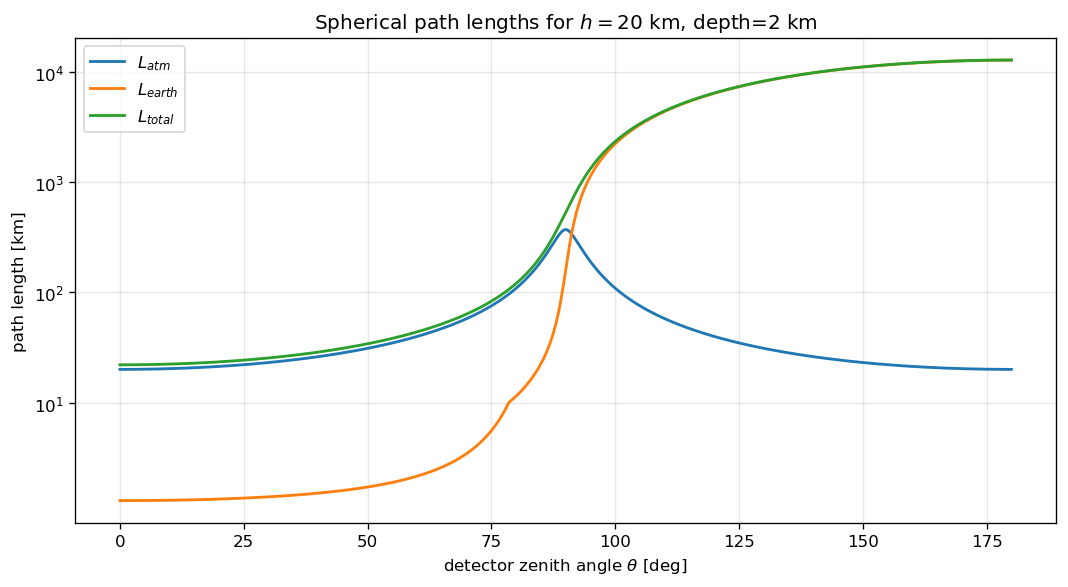

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig3_1_path_lengths.png
max |L_total - L_earth - L_atm| [km]: 0.0


In [5]:
L_total = total_path_length(H0_KM, THETA_GRID_DEG, DEPTH_KM, device=DEVICE, dtype=DTYPE)
L_earth = underground_path_length(THETA_GRID_DEG, DEPTH_KM, device=DEVICE, dtype=DTYPE)
L_atm = atmosphere_path_length(H0_KM, THETA_GRID_DEG, DEPTH_KM, device=DEVICE, dtype=DTYPE)
closure = torch.max(torch.abs(L_total - L_earth - L_atm))

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(to_numpy(THETA_GRID_DEG), to_numpy(L_atm), lw=1.7, label=r"$L_{atm}$")
ax.plot(to_numpy(THETA_GRID_DEG), to_numpy(L_earth), lw=1.7, label=r"$L_{earth}$")
ax.plot(to_numpy(THETA_GRID_DEG), to_numpy(L_total), lw=1.7, label=r"$L_{total}$")
ax.set_yscale("symlog", linthresh=10.0)
ax.set_xlabel(r"detector zenith angle $\theta$ [deg]")
ax.set_ylabel("path length [km]")
ax.set_title(rf"Spherical path lengths for $h={float(H0_KM):.0f}$ km, depth={float(DEPTH_KM):.0f} km")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig3_1_path_lengths.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("max |L_total - L_earth - L_atm| [km]:", float(closure))


### 3.2 Angle Conversions

This section checks the conversion between detector angle $\theta$, Peanuts nadir angle $\eta$, and surface angle $\alpha$.

**Expected results**: $\eta=\pi-	heta$ maps vertical downward to $\eta=\pi$ and vertical upward to $\eta=0$. The detector-to-surface angle is close to the detector angle for shallow detectors but is slightly shifted by depth.


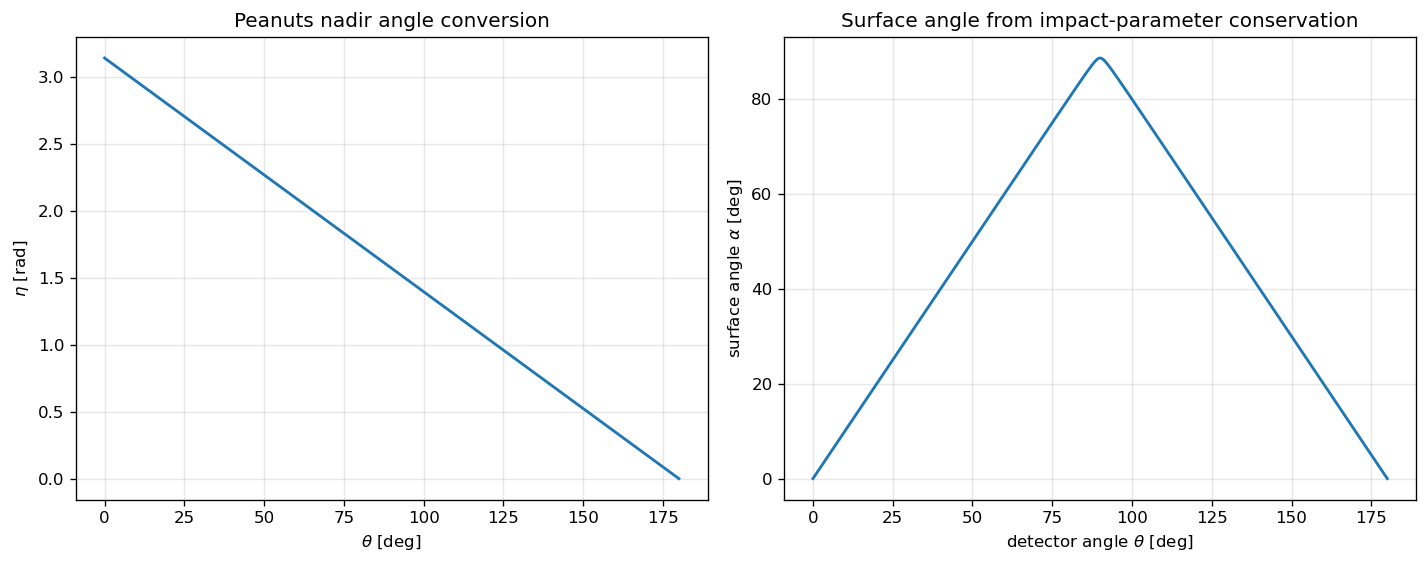

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig3_2_angle_conversions.png
max theta roundtrip residual [deg]: 2.842170943040401e-14


In [6]:
eta = theta_to_eta(THETA_GRID_DEG, device=DEVICE, dtype=DTYPE)
theta_roundtrip = eta_to_theta(eta, device=DEVICE, dtype=DTYPE)
alpha_surface = theta_detector_to_alpha_surface(THETA_GRID_DEG, DEPTH_KM, device=DEVICE, dtype=DTYPE)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
axes[0].plot(to_numpy(THETA_GRID_DEG), to_numpy(eta), lw=1.7)
axes[0].set_xlabel(r"$\theta$ [deg]")
axes[0].set_ylabel(r"$\eta$ [rad]")
axes[0].set_title(r"Peanuts nadir angle conversion")
axes[0].grid(True, alpha=0.3)

axes[1].plot(to_numpy(THETA_GRID_DEG), to_numpy(alpha_surface), lw=1.7)
axes[1].set_xlabel(r"detector angle $\theta$ [deg]")
axes[1].set_ylabel(r"surface angle $\alpha$ [deg]")
axes[1].set_title("Surface angle from impact-parameter conservation")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig3_2_angle_conversions.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("max theta roundtrip residual [deg]:", float(torch.max(torch.abs(theta_roundtrip - THETA_GRID_DEG))))


### 3.3 Altitude Along the Atmosphere Segment

The atmosphere path grid starts at the surface crossing and ends at the selected production altitude.

**Expected results**: altitude should increase monotonically along the atmosphere segment and end at the configured production altitude for each angle.


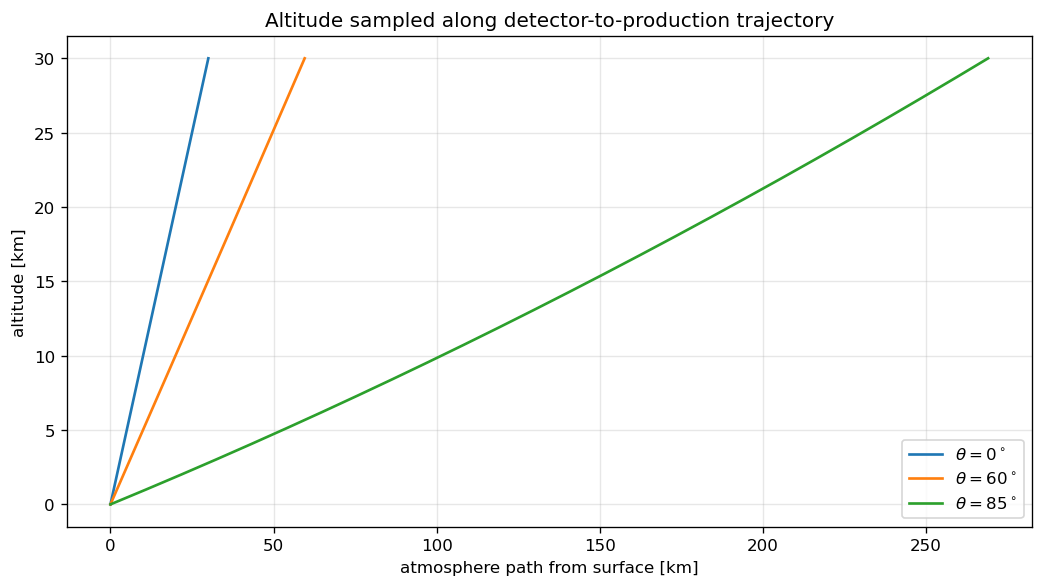

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig3_3_altitude_path_grid.png
final altitudes [km]: [30. 30. 30.]


In [7]:
theta_examples = torch.tensor([0.0, 60.0, 85.0], device=DEVICE, dtype=DTYPE)
s_grid, h_grid = atmosphere_path_grid(30.0, theta_examples, DEPTH_KM, n_steps=200, device=DEVICE, dtype=DTYPE)

fig, ax = plt.subplots(figsize=(8.8, 5.0))
for idx, theta in enumerate(theta_examples):
    ax.plot(to_numpy(s_grid[idx]), to_numpy(h_grid[idx]), lw=1.6, label=rf"$\theta={float(theta):.0f}^\circ$")
ax.set_xlabel("atmosphere path from surface [km]")
ax.set_ylabel("altitude [km]")
ax.set_title("Altitude sampled along detector-to-production trajectory")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig3_3_altitude_path_grid.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("final altitudes [km]:", to_numpy(h_grid[:, -1]))


## 4. Atmospheric Depth

### 4.1 Vertical and Slant Depth

This section builds an exponential mass-density profile and integrates it into vertical atmospheric depth. It then projects the result to slant depths using the plane-parallel approximation.

**Expected results**: vertical depth should decrease with altitude. Slant depth should increase with zenith angle as $1/\cos\alpha$.


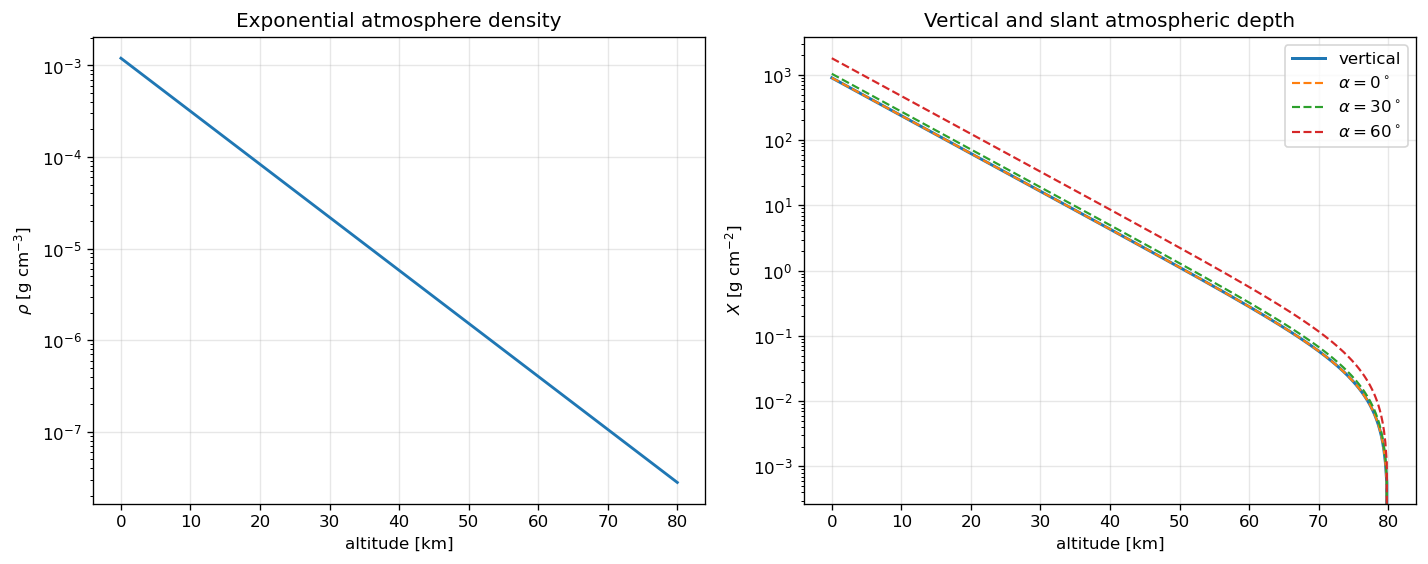

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig4_1_depth_profiles.png
X_vertical(0 km) [g/cm2]: 900.03262092449
X_vertical(top grid) [g/cm2]: 0.0


In [8]:
rho_exp = atmosphere_mass_density_profile_exponential(ALTITUDE_GRID_KM, rho0_gcm3=EXP_RHO0, scale_height_km=EXP_H, context=ctx)
X_vertical = atmosphere_vertical_depth(ALTITUDE_GRID_KM, rho_exp, device=DEVICE, dtype=DTYPE)
X_slant = atmosphere_slant_depth(X_vertical, ALPHA_DEPTH_DEG, device=DEVICE, dtype=DTYPE)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharex=True)
axes[0].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(rho_exp), lw=1.7)
axes[0].set_yscale("log")
axes[0].set_xlabel("altitude [km]")
axes[0].set_ylabel(r"$\rho$ [g cm$^{-3}$]")
axes[0].set_title("Exponential atmosphere density")
axes[0].grid(True, alpha=0.3)

axes[1].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(X_vertical), lw=1.8, label=r"vertical")
for idx, alpha in enumerate(ALPHA_DEPTH_DEG):
    axes[1].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(X_slant[idx]), lw=1.3, ls="--", label=rf"$\alpha={float(alpha):.0f}^\circ$")
axes[1].set_yscale("log")
axes[1].set_xlabel("altitude [km]")
axes[1].set_ylabel(r"$X$ [g cm$^{-2}$]")
axes[1].set_title("Vertical and slant atmospheric depth")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig4_1_depth_profiles.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("X_vertical(0 km) [g/cm2]:", float(X_vertical[0]))
print("X_vertical(top grid) [g/cm2]:", float(X_vertical[-1]))


### 4.2 Numerical Derivative of Depth

Since $X(h)=\int_h^\inftyho(h')dh'$, the derivative should satisfy approximately

$$
\frac{dX}{dh}\approx -\rho(h)\,10^5,
$$

where $10^5$ converts km to cm.

**Expected results**: the numerical derivative should track $-\rho\,10^5$, with small edge/interpolation differences from the finite grid.


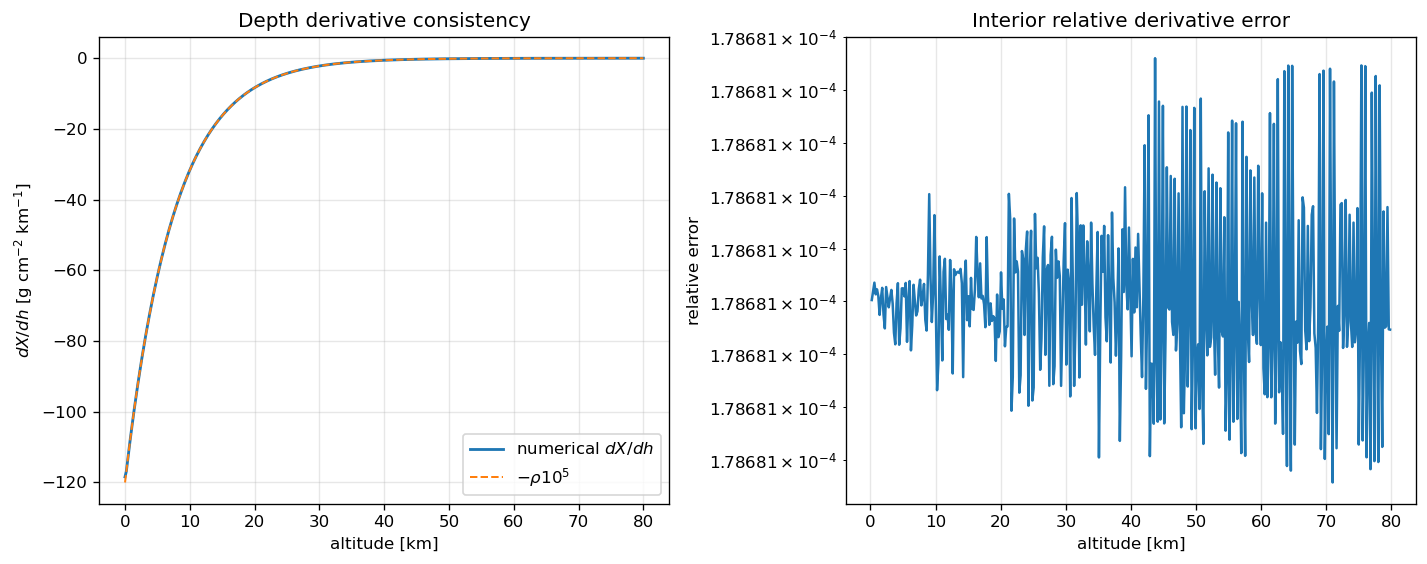

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig4_2_depth_derivative.png
median interior relative derivative error: 0.00017868065238931387
max interior relative derivative error: 0.00017868065241300756


In [9]:
dXdh = compute_dXdh(X_vertical, ALTITUDE_GRID_KM, device=DEVICE, dtype=DTYPE)
expected_dXdh = -rho_exp * 1.0e5
rel = relative_error(dXdh[1:-1], expected_dXdh[1:-1])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
axes[0].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(dXdh), lw=1.7, label=r"numerical $dX/dh$")
axes[0].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(expected_dXdh), lw=1.2, ls="--", label=r"$-\rho 10^5$")
axes[0].set_xlabel("altitude [km]")
axes[0].set_ylabel(r"$dX/dh$ [g cm$^{-2}$ km$^{-1}$]")
axes[0].set_title("Depth derivative consistency")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(to_numpy(ALTITUDE_GRID_KM[1:-1]), to_numpy(rel), lw=1.5)
axes[1].set_xlabel("altitude [km]")
axes[1].set_ylabel("relative error")
axes[1].set_title("Interior relative derivative error")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig4_2_depth_derivative.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("median interior relative derivative error:", float(torch.median(rel)))
print("max interior relative derivative error:", float(torch.max(rel)))


## 5. Density Models

### 5.1 Exponential and nuSQuIDS EarthAtm Density

The nuSQuIDS EarthAtm density helper is a torch-native implementation of the exponential formula used by the external nuSQuIDS atmosphere body. This plot compares it with the package exponential defaults.

**Expected results**: both curves should be smooth exponentials with slightly different scale-height/default-parameter choices.


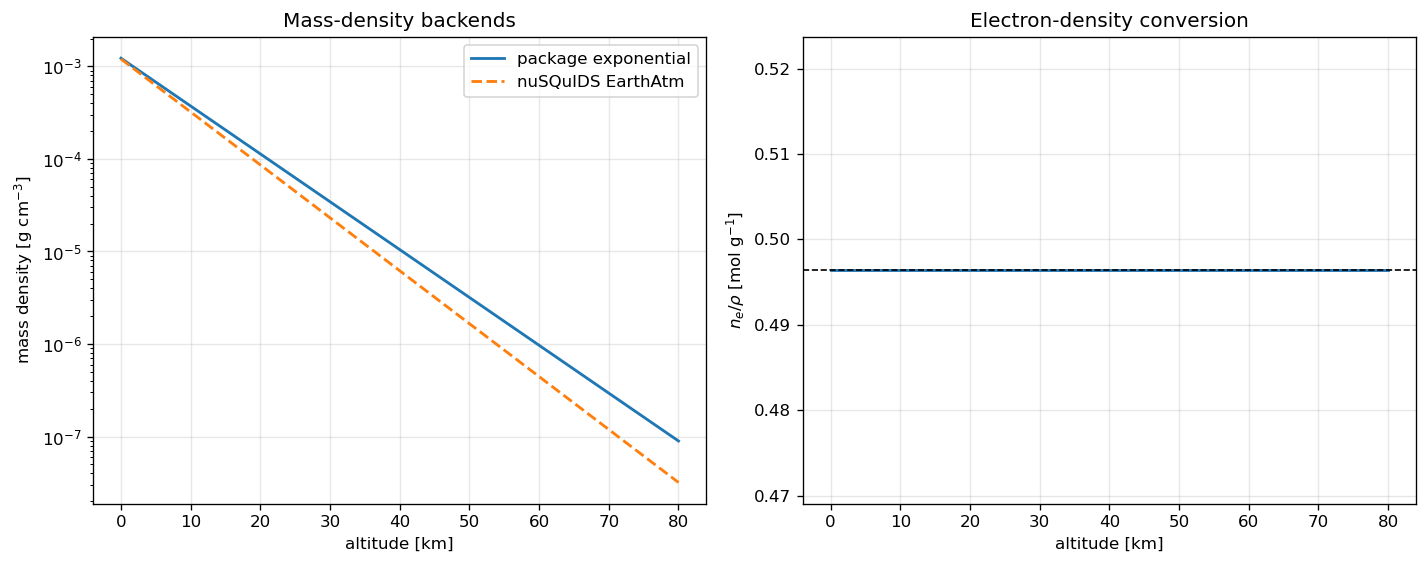

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig5_1_density_models.png


In [10]:
rho_default = atmosphere_density(ALTITUDE_GRID_KM, source="exponential", density_type="mass_density", context=ctx)
nus_config = NuSQuIDSConfig()
rho_nus = atmosphere_density(ALTITUDE_GRID_KM, source="nusquids", density_type="mass_density", nusquids_config=nus_config, context=ctx)
ne_default = atmosphere_density(ALTITUDE_GRID_KM, source="exponential", density_type="electron_density", Ye=YE, context=ctx)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharex=True)
axes[0].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(rho_default), lw=1.7, label="package exponential")
axes[0].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(rho_nus), lw=1.7, ls="--", label="nuSQuIDS EarthAtm")
axes[0].set_yscale("log")
axes[0].set_xlabel("altitude [km]")
axes[0].set_ylabel(r"mass density [g cm$^{-3}$]")
axes[0].set_title("Mass-density backends")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

conversion_ratio = ne_default / torch.clamp(rho_default, min=torch.finfo(DTYPE).tiny)
axes[1].plot(to_numpy(ALTITUDE_GRID_KM), to_numpy(conversion_ratio), lw=1.7)
axes[1].axhline(float(YE * GCM3_TO_NUCLEON_MOLCM3), color="black", lw=1.0, ls="--")
axes[1].set_xlabel("altitude [km]")
axes[1].set_ylabel(r"$n_e/\rho$ [mol g$^{-1}$]")
axes[1].set_title("Electron-density conversion")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig5_1_density_models.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 5.2 File-Based Density Interpolation

The file backend reads a two-column altitude-density table and linearly interpolates it, clamping outside the file range to endpoint values.

**Expected results**: interpolation should pass through the tabulated points and remain finite outside the sampled range.


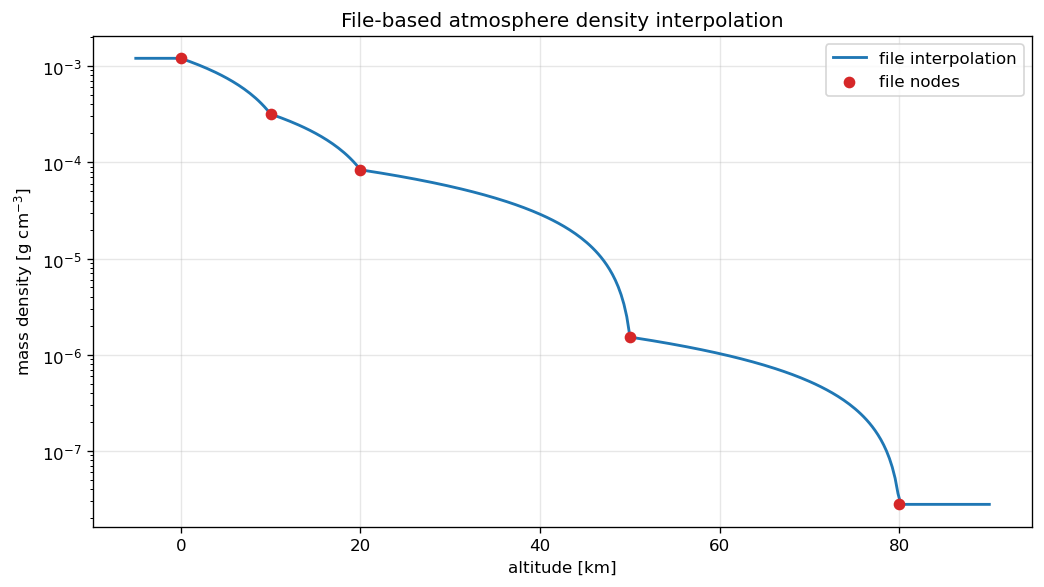

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig5_2_file_density_interpolation.png
generated density file: v:\output\diagnostic\atmosphere\diagnostic_density_profile.txt


In [11]:
density_file = OUTPUT_DIR / "diagnostic_density_profile.txt"
file_h = torch.tensor([0.0, 10.0, 20.0, 50.0, 80.0], device=DEVICE, dtype=DTYPE)
file_rho = atmosphere_mass_density_profile_exponential(file_h, rho0_gcm3=EXP_RHO0, scale_height_km=EXP_H, context=ctx)
with density_file.open("w", encoding="utf-8") as handle:
    handle.write("# h_km rho_gcm3\n")
    for h_val, rho_val in zip(to_numpy(file_h), to_numpy(file_rho)):
        handle.write(f"{h_val:.8e} {rho_val:.12e}\n")

query_h = torch.linspace(-5.0, 90.0, 300, device=DEVICE, dtype=DTYPE)
rho_file = atmosphere_mass_density_profile_from_file(query_h, str(density_file), context=ctx)

fig, ax = plt.subplots(figsize=(8.8, 5.0))
ax.plot(to_numpy(query_h), to_numpy(rho_file), lw=1.7, label="file interpolation")
ax.scatter(to_numpy(file_h), to_numpy(file_rho), color="C3", zorder=3, label="file nodes")
ax.set_yscale("log")
ax.set_xlabel("altitude [km]")
ax.set_ylabel(r"mass density [g cm$^{-3}$]")
ax.set_title("File-based atmosphere density interpolation")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig5_2_file_density_interpolation.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("generated density file:", density_file)


## 6. Numerical AtmosphereProfile

`AtmosphereProfile` combines path geometry and density evaluation into the object consumed by numerical propagation code.

**Expected results**: altitude samples should increase along the atmosphere path. Electron density should decrease with altitude for the exponential backend and become exactly zero when `matter=False`.


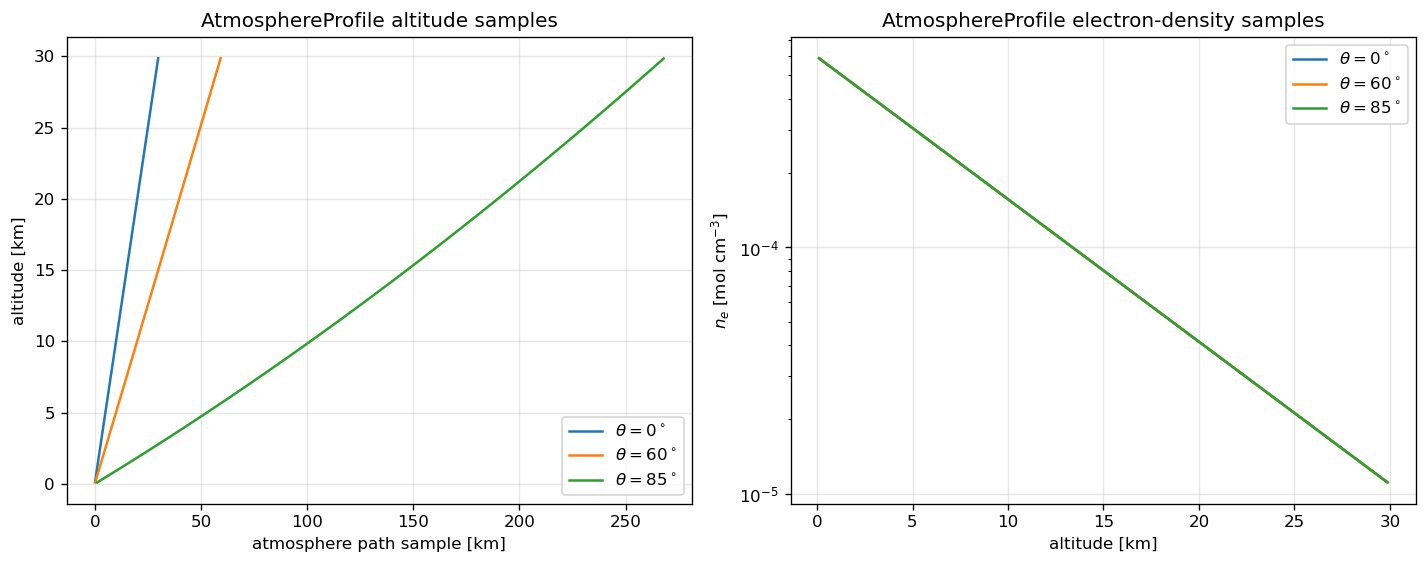

v:\output\diagnostic\atmosphere\diagnostic1_atmosphere_fig6_1_profile_samples.png


,theta_deg,L_atm_km,L_earth_km,nsteps,ne_min,ne_max
0,0.0,30.000000,2.000000,120,0.000011,0.000586
1,60.0,59.529014,3.998118,120,0.000011,0.000586
2,85.0,269.032779,22.495220,120,0.000011,0.000588


In [12]:
params = AtmosphereParameters(
    atmosphere_density_source="exponential",
    atmosphere_density_kwargs={"rho0_gcm3": float(EXP_RHO0), "scale_height_km": float(EXP_H), "Ye": float(YE)},
    nsteps=120,
    method="midpoint",
    matter=True,
    evolution_scale_m=R_E,
)
profile_angles = torch.tensor([0.0, 60.0, 85.0], device=DEVICE, dtype=DTYPE)
profiles = [AtmosphereProfile(30.0, theta, DEPTH_KM, params=params, context=ctx) for theta in profile_angles]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
for theta, profile in zip(profile_angles, profiles):
    s_km = profile.trajectory.sample_x * (torch.as_tensor(R_E, device=DEVICE, dtype=DTYPE) / 1.0e3)
    axes[0].plot(to_numpy(s_km), to_numpy(profile.altitude_km), lw=1.5, label=rf"$\theta={float(theta):.0f}^\circ$")
    axes[1].semilogy(to_numpy(profile.altitude_km), to_numpy(profile.n_e_molcm3), lw=1.5, label=rf"$\theta={float(theta):.0f}^\circ$")

axes[0].set_xlabel("atmosphere path sample [km]")
axes[0].set_ylabel("altitude [km]")
axes[0].set_title("AtmosphereProfile altitude samples")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("altitude [km]")
axes[1].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[1].set_title("AtmosphereProfile electron-density samples")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
save_and_show("diagnostic1_atmosphere_fig6_1_profile_samples.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

summary = pd.DataFrame([
    {
        "theta_deg": float(theta),
        "L_atm_km": float(profile.L_atm_km),
        "L_earth_km": float(profile.L_und_km),
        "nsteps": profile.nsteps,
        "ne_min": float(profile.n_e_molcm3.min()),
        "ne_max": float(profile.n_e_molcm3.max()),
    }
    for theta, profile in zip(profile_angles, profiles)
])
display(summary)


### 6.2 Matter-Off Profile

The same trajectory can be used in vacuum mode by setting `matter=False`.

**Expected results**: the trajectory and altitude samples still exist, but the stored electron density is exactly zero.


In [13]:
vacuum_params = AtmosphereParameters(
    atmosphere_density_source="exponential",
    atmosphere_density_kwargs={"rho0_gcm3": float(EXP_RHO0), "scale_height_km": float(EXP_H), "Ye": float(YE)},
    nsteps=40,
    method="midpoint",
    matter=False,
    evolution_scale_m=R_E,
)
vacuum_profile = AtmosphereProfile(20.0, 45.0, DEPTH_KM, params=vacuum_params, context=ctx)
print(f"AtmosphereProfile: source={vacuum_profile.atmosphere_density_source}, h_km={float(vacuum_profile.h_km):.1f}, theta_deg={float(vacuum_profile.theta_deg):.1f}, depth_km={float(vacuum_profile.depth_km):.2f}, nsteps={vacuum_profile.nsteps}, matter={vacuum_profile.matter}")
print("max |n_e|:", float(torch.max(torch.abs(vacuum_profile.n_e_molcm3))))


AtmosphereProfile: source=exponential, h_km=20.0, theta_deg=45.0, depth_km=2.00, nsteps=40, matter=False
max |n_e|: 0.0


## 7. Summary

The atmosphere geometry layer follows the expected spherical ray/shell relations and preserves the identity $L_{total}=L_{earth}+L_{atm}$. The angle diagnostics clarify the distinction between detector zenith angle $\theta$, Peanuts nadir angle $\eta$, and surface angle $\alpha$.

The depth layer converts density profiles into vertical overburden and slant depth, with the numerical derivative recovering $dX/dh\approx-\rho\,10^5$. The density layer provides deterministic exponential, nuSQuIDS-style, and file-interpolated profiles, and the electron-density conversion remains a simple multiplicative factor for non-PyMSIS backends.

Finally, `AtmosphereProfile` ties these pieces together by sampling the altitude and electron density along the atmosphere segment used by numerical propagation. Matter-on profiles show decreasing electron density with altitude, while matter-off profiles preserve the trajectory but set the density to zero.
